# CS3807 – Experiment 7: Autoencoders, CAE, Denoising AE and VAE (MNIST)

## 0. Setup

In [26]:
import os, re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# ---- save every plot into the Figures/ folder ----
FIG_DIR = 'Figures'
os.makedirs(FIG_DIR, exist_ok=True)
_count = [0]
_orig_show = plt.show
def _save_and_show(*a, **k):
    for num in plt.get_fignums():
        fig = plt.figure(num)
        if getattr(fig, '_suptitle', None) is not None:
            title = fig._suptitle.get_text()
        else:
            title = fig.axes[0].get_title() if fig.axes else ''
        slug = re.sub(r'[^a-z0-9]+', '_', title.lower()).strip('_')[:60] or 'figure'
        _count[0] += 1
        fig.savefig(f'{FIG_DIR}/{_count[0]:02d}_{slug}.png', dpi=200, bbox_inches='tight')
    _orig_show(*a, **k)
    plt.close('all')
plt.show = _save_and_show

In [27]:
# Data: 10,000 train / 2,000 test, normalised to [0, 1]
(xtr_f, ytr_f), (xte_f, yte_f) = keras.datasets.mnist.load_data()
x_train = (xtr_f[:10000].astype('float32') / 255.)[..., None]
x_test  = (xte_f[:2000].astype('float32') / 255.)[..., None]
y_test  = yte_f[:2000]

x_tr, x_val = x_train[:9000], x_train[9000:]      # train / validation split
print(x_tr.shape, x_val.shape, x_test.shape)

(9000, 28, 28, 1) (1000, 28, 28, 1) (2000, 28, 28, 1)


In [28]:
def ssim_mean(x, xh):
    return float(np.mean([ssim(a, b, data_range=1.0) for a, b in zip(x.squeeze(-1), xh.squeeze(-1))]))

def evaluate(x, xh):
    return dict(MSE=float(np.mean((x - xh) ** 2)),
                MAE=float(np.mean(np.abs(x - xh))),
                SSIM=ssim_mean(x, xh))

def show_rows(rows, n=10, title=None):
    fig, axes = plt.subplots(len(rows), n, figsize=(n * 1.2, len(rows) * 1.4))
    axes = np.atleast_2d(axes)
    for r, row in enumerate(rows):
        name, imgs = row[0], row[1]
        cmap = row[2] if len(row) > 2 else 'gray'
        for c in range(n):
            axes[r, c].imshow(imgs[c].squeeze(), cmap=cmap, vmin=0, vmax=1)
            axes[r, c].axis('off')
        axes[r, 0].text(-0.15, 0.5, name, transform=axes[r, 0].transAxes, ha='right', va='center')
    if title: fig.suptitle(title, y=1.02)
    plt.subplots_adjust(left=0.12)
    plt.show()

def fit_ae(model, x, y, epochs=20, bs=128, verbose=2):
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    t0 = time.time()
    h = model.fit(x, y, validation_data=(x_val if x is x_tr else x_val_in, x_val),
                  epochs=epochs, batch_size=bs, shuffle=True, verbose=verbose)
    return h.history, time.time() - t0

x_val_in = x_val     # validation input (replaced by a noisy copy for denoisers)
results = {}

## 1. Fully Connected Autoencoder

In [29]:
def build_fc_ae(latent_dim=16):
    inp = keras.Input((28, 28, 1))
    x = layers.Flatten()(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    z = layers.Dense(latent_dim)(x)
    x = layers.Dense(32, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(784, activation='sigmoid')(x)
    return keras.Model(inp, layers.Reshape((28, 28, 1))(x))

fc_ae = build_fc_ae(16)
fc_hist, fc_time = fit_ae(fc_ae, x_tr, x_tr)

Epoch 1/20
71/71 - 5s - 72ms/step - loss: 0.3516 - val_loss: 0.2606
Epoch 2/20
71/71 - 1s - 15ms/step - loss: 0.2299 - val_loss: 0.2075
Epoch 3/20
71/71 - 1s - 12ms/step - loss: 0.1924 - val_loss: 0.1844
Epoch 4/20
71/71 - 1s - 11ms/step - loss: 0.1720 - val_loss: 0.1697
Epoch 5/20
71/71 - 1s - 12ms/step - loss: 0.1610 - val_loss: 0.1613
Epoch 6/20
71/71 - 1s - 15ms/step - loss: 0.1527 - val_loss: 0.1545
Epoch 7/20
71/71 - 1s - 20ms/step - loss: 0.1460 - val_loss: 0.1489
Epoch 8/20
71/71 - 2s - 32ms/step - loss: 0.1413 - val_loss: 0.1453
Epoch 9/20
71/71 - 2s - 29ms/step - loss: 0.1381 - val_loss: 0.1426
Epoch 10/20
71/71 - 2s - 32ms/step - loss: 0.1356 - val_loss: 0.1405
Epoch 11/20
71/71 - 2s - 27ms/step - loss: 0.1336 - val_loss: 0.1388
Epoch 12/20
71/71 - 3s - 37ms/step - loss: 0.1318 - val_loss: 0.1374
Epoch 13/20
71/71 - 1s - 16ms/step - loss: 0.1303 - val_loss: 0.1361
Epoch 14/20
71/71 - 2s - 23ms/step - loss: 0.1288 - val_loss: 0.1348
Epoch 15/20
71/71 - 1s - 19ms/step - loss: 

**Plot 1** – Original vs Reconstruction vs Error, **Plot 2** – Training/Validation loss

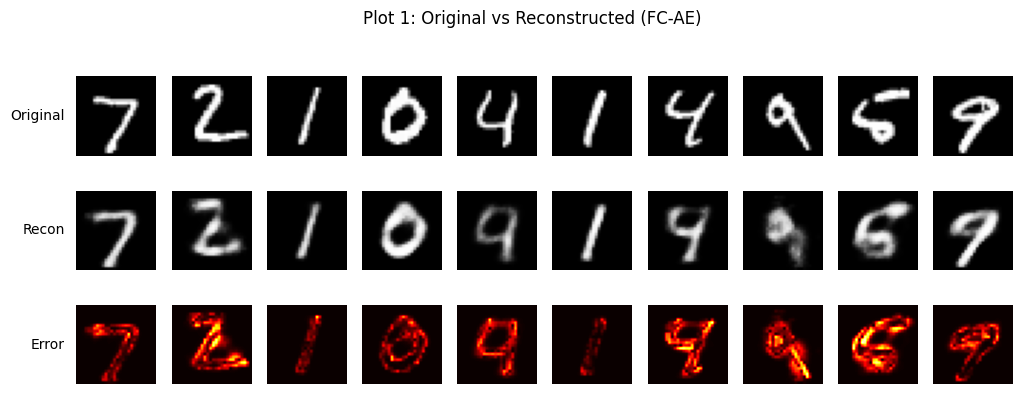

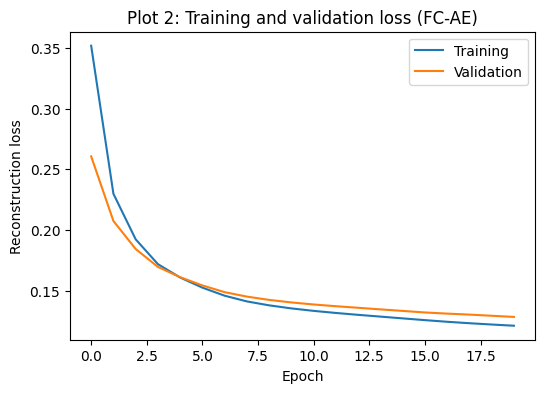

In [30]:
fc_rec = fc_ae.predict(x_test, verbose=0)
show_rows([("Original", x_test[:10]),
           ("Recon", fc_rec[:10]),
           ("Error", np.abs(x_test[:10] - fc_rec[:10]), 'hot')],
          title="Plot 1: Original vs Reconstructed (FC-AE)")

plt.figure(figsize=(6, 4))
plt.plot(fc_hist['loss'], label='Training')
plt.plot(fc_hist['val_loss'], label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Reconstruction loss'); plt.legend()
plt.title('Plot 2: Training and validation loss (FC-AE)')
plt.show()

In [31]:
fc_m = evaluate(x_test, fc_rec)
results['FC Autoencoder'] = dict(**fc_m, Parameters=fc_ae.count_params(), Time=fc_time)
pd.DataFrame({'Metric': ['Test MSE', 'Test MAE', 'Mean SSIM'],
              'Value': [fc_m['MSE'], fc_m['MAE'], fc_m['SSIM']]})

,Metric,Value
0,Test MSE,0.02135
1,Test MAE,0.05662
2,Mean SSIM,0.74932


## 2. Convolutional Autoencoder

In [32]:
def build_cae():
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    return keras.Model(inp, out)

cae = build_cae()
cae_hist, cae_time = fit_ae(cae, x_tr, x_tr)

Epoch 1/20
71/71 - 13s - 189ms/step - loss: 0.2618 - val_loss: 0.1141
Epoch 2/20
71/71 - 8s - 115ms/step - loss: 0.0958 - val_loss: 0.0901
Epoch 3/20
71/71 - 9s - 133ms/step - loss: 0.0847 - val_loss: 0.0849
Epoch 4/20
71/71 - 9s - 123ms/step - loss: 0.0804 - val_loss: 0.0803
Epoch 5/20
71/71 - 11s - 151ms/step - loss: 0.0775 - val_loss: 0.0778
Epoch 6/20
71/71 - 10s - 137ms/step - loss: 0.0755 - val_loss: 0.0764
Epoch 7/20
71/71 - 9s - 128ms/step - loss: 0.0741 - val_loss: 0.0756
Epoch 8/20
71/71 - 9s - 133ms/step - loss: 0.0731 - val_loss: 0.0748
Epoch 9/20
71/71 - 9s - 129ms/step - loss: 0.0724 - val_loss: 0.0735
Epoch 10/20
71/71 - 11s - 161ms/step - loss: 0.0717 - val_loss: 0.0728
Epoch 11/20
71/71 - 9s - 127ms/step - loss: 0.0711 - val_loss: 0.0722
Epoch 12/20
71/71 - 10s - 145ms/step - loss: 0.0707 - val_loss: 0.0717
Epoch 13/20
71/71 - 9s - 134ms/step - loss: 0.0702 - val_loss: 0.0713
Epoch 14/20
71/71 - 10s - 139ms/step - loss: 0.0699 - val_loss: 0.0709
Epoch 15/20
71/71 - 9s 

**FC-AE vs CAE table** and **Plot 3**

In [33]:
cae_rec = cae.predict(x_test, verbose=0)
cae_m = evaluate(x_test, cae_rec)
results['Conv. Autoencoder'] = dict(**cae_m, Parameters=cae.count_params(), Time=cae_time)

pd.DataFrame({'Model': ['Fully Connected AE', 'Convolutional AE'],
              'MSE': [fc_m['MSE'], cae_m['MSE']],
              'MAE': [fc_m['MAE'], cae_m['MAE']],
              'SSIM': [fc_m['SSIM'], cae_m['SSIM']],
              'Parameters': [fc_ae.count_params(), cae.count_params()]})

,Model,MSE,MAE,SSIM,Parameters
0,Fully Connected AE,0.02135,0.05662,0.74932,211040
1,Convolutional AE,0.00258,0.01496,0.97423,74497


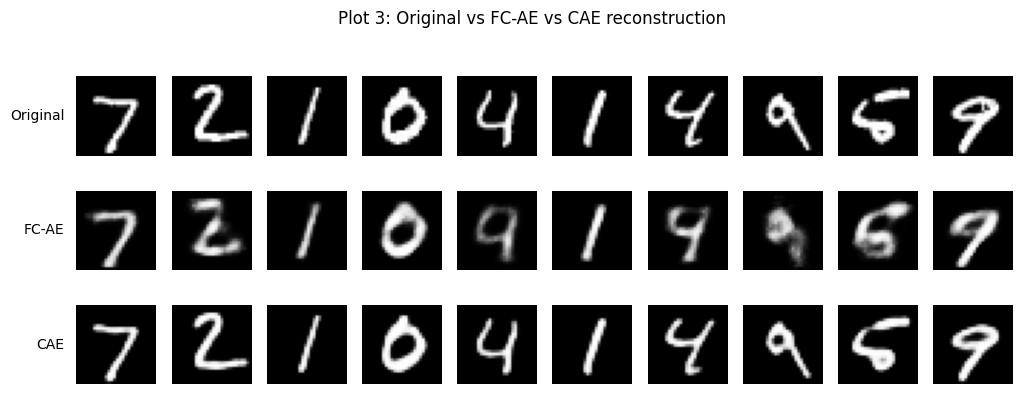

In [34]:
show_rows([("Original", x_test[:10]), ("FC-AE", fc_rec[:10]), ("CAE", cae_rec[:10])],
          title="Plot 3: Original vs FC-AE vs CAE reconstruction")

## 3. Denoising Autoencoder (Gaussian and Salt-and-Pepper noise)

In [35]:
def add_gaussian(x, sigma, rng):
    return np.clip(x + rng.normal(0., sigma, x.shape), 0., 1.).astype('float32')

def add_salt_pepper(x, p, rng):
    r = rng.random(x.shape)
    out = x.copy()
    out[r < p / 2] = 0.0
    out[(r >= p / 2) & (r < p)] = 1.0
    return out.astype('float32')

def train_denoiser(noise_fn, level):
    global x_val_in
    model = build_cae()
    x_val_in = noise_fn(x_val, level, np.random.default_rng(1))
    xn = noise_fn(x_tr, level, rng)                  # noisy input, CLEAN target
    hist, t = fit_ae(model, xn, x_tr)
    x_val_in = x_val
    return model, t

def eval_levels(model, noise_fn, levels):
    rows = []
    for lv in levels:
        xn = noise_fn(x_test, lv, np.random.default_rng(100))
        m = evaluate(x_test, model.predict(xn, verbose=0))
        rows.append({'Noise Level': lv, **m})
    return pd.DataFrame(rows)

**Gaussian noise** (trained at σ = 0.2): Plot 4 and Plot 5

Epoch 1/20
71/71 - 11s - 157ms/step - loss: 0.2649 - val_loss: 0.1288
Epoch 2/20
71/71 - 8s - 112ms/step - loss: 0.1100 - val_loss: 0.1015
Epoch 3/20
71/71 - 10s - 134ms/step - loss: 0.0956 - val_loss: 0.0937
Epoch 4/20
71/71 - 10s - 143ms/step - loss: 0.0897 - val_loss: 0.0904
Epoch 5/20
71/71 - 9s - 129ms/step - loss: 0.0863 - val_loss: 0.0867
Epoch 6/20
71/71 - 9s - 125ms/step - loss: 0.0841 - val_loss: 0.0848
Epoch 7/20
71/71 - 9s - 126ms/step - loss: 0.0827 - val_loss: 0.0841
Epoch 8/20
71/71 - 8s - 107ms/step - loss: 0.0817 - val_loss: 0.0835
Epoch 9/20
71/71 - 8s - 119ms/step - loss: 0.0805 - val_loss: 0.0820
Epoch 10/20
71/71 - 9s - 124ms/step - loss: 0.0799 - val_loss: 0.0815
Epoch 11/20
71/71 - 8s - 112ms/step - loss: 0.0794 - val_loss: 0.0815
Epoch 12/20
71/71 - 8s - 108ms/step - loss: 0.0786 - val_loss: 0.0811
Epoch 13/20
71/71 - 8s - 111ms/step - loss: 0.0783 - val_loss: 0.0803
Epoch 14/20
71/71 - 7s - 101ms/step - loss: 0.0777 - val_loss: 0.0803
Epoch 15/20
71/71 - 7s - 1

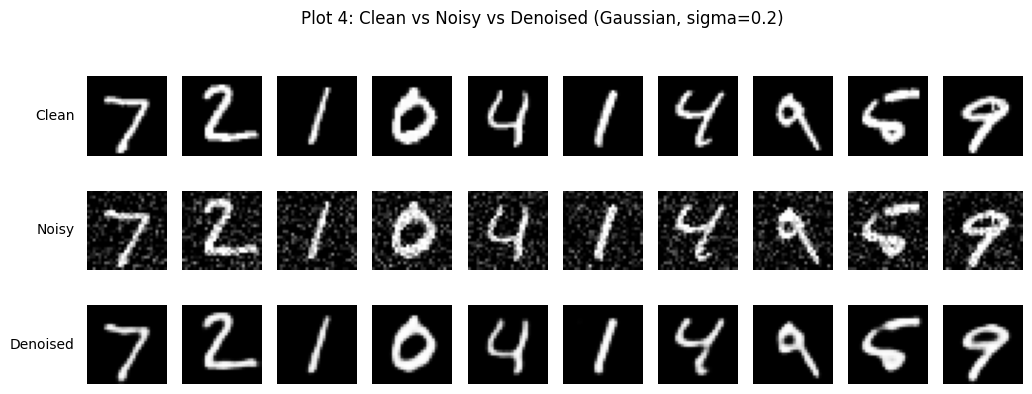

In [36]:
dae_g, dae_g_time = train_denoiser(add_gaussian, 0.2)

xn = add_gaussian(x_test[:10], 0.2, np.random.default_rng(7))
show_rows([("Clean", x_test[:10]), ("Noisy", xn), ("Denoised", dae_g.predict(xn, verbose=0))],
          title="Plot 4: Clean vs Noisy vs Denoised (Gaussian, sigma=0.2)")

,Noise Level,MSE,MAE,SSIM
0,0.10000,0.00378,0.01829,0.95614
1,0.20000,0.00494,0.02200,0.94174
2,0.30000,0.00755,0.02978,0.87907


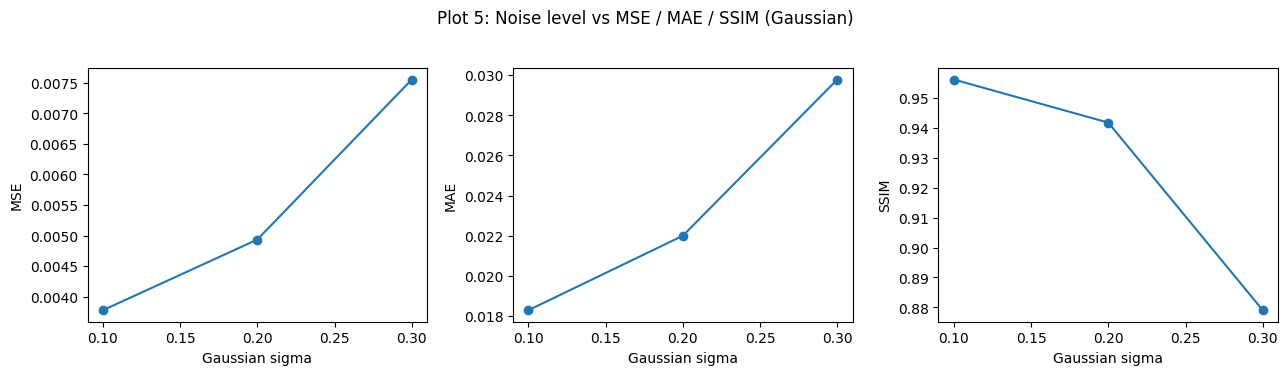

In [37]:
df_g = eval_levels(dae_g, add_gaussian, [0.1, 0.2, 0.3])
display(df_g)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, m in zip(ax, ['MSE', 'MAE', 'SSIM']):
    a.plot(df_g['Noise Level'], df_g[m], 'o-')
    a.set_xlabel('Gaussian sigma'); a.set_ylabel(m)
fig.suptitle('Plot 5: Noise level vs MSE / MAE / SSIM (Gaussian)', y=1.03)
plt.tight_layout(); plt.show()

xn02 = add_gaussian(x_test, 0.2, np.random.default_rng(100))
results['Denoising CAE'] = dict(**evaluate(x_test, dae_g.predict(xn02, verbose=0)),
                                Parameters=dae_g.count_params(), Time=dae_g_time)

**Salt-and-pepper noise** (trained at p = 0.10)

Epoch 1/20
71/71 - 12s - 165ms/step - loss: 0.2586 - val_loss: 0.1334
Epoch 2/20
71/71 - 7s - 102ms/step - loss: 0.1112 - val_loss: 0.1012
Epoch 3/20
71/71 - 8s - 109ms/step - loss: 0.0944 - val_loss: 0.0932
Epoch 4/20
71/71 - 9s - 128ms/step - loss: 0.0893 - val_loss: 0.0897
Epoch 5/20
71/71 - 8s - 118ms/step - loss: 0.0869 - val_loss: 0.0877
Epoch 6/20
71/71 - 11s - 152ms/step - loss: 0.0846 - val_loss: 0.0856
Epoch 7/20
71/71 - 10s - 141ms/step - loss: 0.0833 - val_loss: 0.0842
Epoch 8/20
71/71 - 9s - 127ms/step - loss: 0.0820 - val_loss: 0.0832
Epoch 9/20
71/71 - 8s - 117ms/step - loss: 0.0810 - val_loss: 0.0824
Epoch 10/20
71/71 - 9s - 125ms/step - loss: 0.0802 - val_loss: 0.0815
Epoch 11/20
71/71 - 8s - 119ms/step - loss: 0.0795 - val_loss: 0.0808
Epoch 12/20
71/71 - 8s - 117ms/step - loss: 0.0789 - val_loss: 0.0803
Epoch 13/20
71/71 - 8s - 118ms/step - loss: 0.0784 - val_loss: 0.0798
Epoch 14/20
71/71 - 9s - 124ms/step - loss: 0.0779 - val_loss: 0.0795
Epoch 15/20
71/71 - 8s - 1

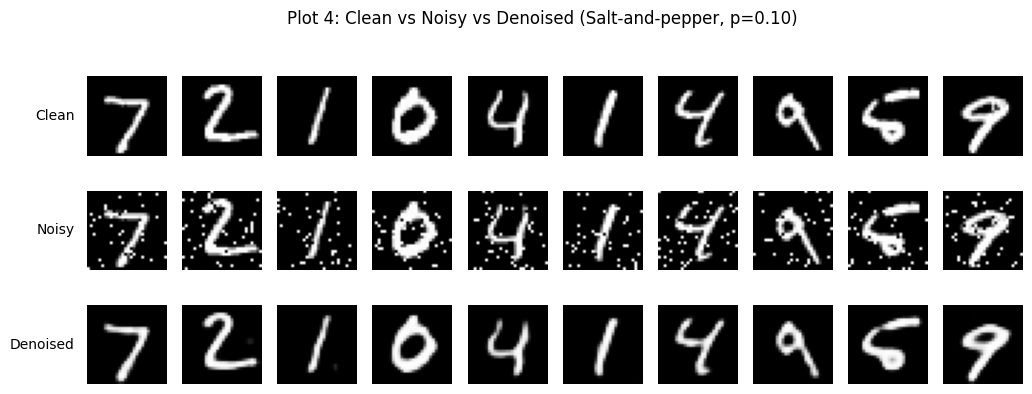

,Noise Level,MSE,MAE,SSIM
0,0.05000,0.00406,0.01894,0.95700
1,0.10000,0.00492,0.02114,0.94494
2,0.20000,0.00804,0.02857,0.89202


In [38]:
dae_sp, _ = train_denoiser(add_salt_pepper, 0.10)

xn = add_salt_pepper(x_test[:10], 0.10, np.random.default_rng(7))
show_rows([("Clean", x_test[:10]), ("Noisy", xn), ("Denoised", dae_sp.predict(xn, verbose=0))],
          title="Plot 4: Clean vs Noisy vs Denoised (Salt-and-pepper, p=0.10)")
display(eval_levels(dae_sp, add_salt_pepper, [0.05, 0.10, 0.20]))

## 4. Variational Autoencoder (latent dimension = 2)

In [39]:
LATENT = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps          # reparameterization trick

inp = keras.Input((28, 28, 1))
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inp)
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)
mu = layers.Dense(LATENT, name='z_mean')(x)
logvar = layers.Dense(LATENT, name='z_log_var')(x)
z = Sampling()([mu, logvar])
encoder = keras.Model(inp, [mu, logvar, z], name='encoder')

dinp = keras.Input((LATENT,))
x = layers.Dense(7 * 7 * 64, activation='relu')(dinp)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
out = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)
decoder = keras.Model(dinp, out, name='decoder')

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kw):
        super().__init__(**kw)
        self.encoder, self.decoder = encoder, decoder
        self.total_tracker = keras.metrics.Mean(name='loss')
        self.rec_tracker = keras.metrics.Mean(name='rec_loss')
        self.kl_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def vae_losses(self, x):
        mu, logvar, z = self.encoder(x)
        xh = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, xh), axis=(1, 2)))
        kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
        return rec, kl

    def _update(self, rec, kl):
        self.total_tracker.update_state(rec + kl)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            rec, kl = self.vae_losses(x)
            total = rec + kl
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update(rec, kl)

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        rec, kl = self.vae_losses(x)
        return self._update(rec, kl)

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
t0 = time.time()
vh = vae.fit(x_tr, x_tr, validation_data=(x_val, x_val), epochs=30,
             batch_size=128, shuffle=True, verbose=2).history
vae_time = time.time() - t0

Epoch 1/30
71/71 - 13s - 188ms/step - kl_loss: 1.3609 - loss: 308.3249 - rec_loss: 306.9641 - val_kl_loss: 0.0157 - val_loss: 216.1140 - val_rec_loss: 216.0983
Epoch 2/30
71/71 - 7s - 93ms/step - kl_loss: 0.3136 - loss: 208.6127 - rec_loss: 208.2990 - val_kl_loss: 1.7038 - val_loss: 202.4134 - val_rec_loss: 200.7096
Epoch 3/30
71/71 - 7s - 104ms/step - kl_loss: 2.1482 - loss: 196.5715 - rec_loss: 194.4233 - val_kl_loss: 2.4289 - val_loss: 194.4343 - val_rec_loss: 192.0054
Epoch 4/30
71/71 - 6s - 90ms/step - kl_loss: 2.6725 - loss: 191.1273 - rec_loss: 188.4548 - val_kl_loss: 3.5684 - val_loss: 187.2932 - val_rec_loss: 183.7248
Epoch 5/30
71/71 - 6s - 81ms/step - kl_loss: 3.8731 - loss: 180.4086 - rec_loss: 176.5355 - val_kl_loss: 4.0537 - val_loss: 178.7248 - val_rec_loss: 174.6711
Epoch 6/30
71/71 - 6s - 89ms/step - kl_loss: 4.1871 - loss: 174.9600 - rec_loss: 170.7729 - val_kl_loss: 4.2165 - val_loss: 176.5428 - val_rec_loss: 172.3263
Epoch 7/30
71/71 - 7s - 94ms/step - kl_loss: 4.38

**Plot 9** – VAE training/validation reconstruction loss

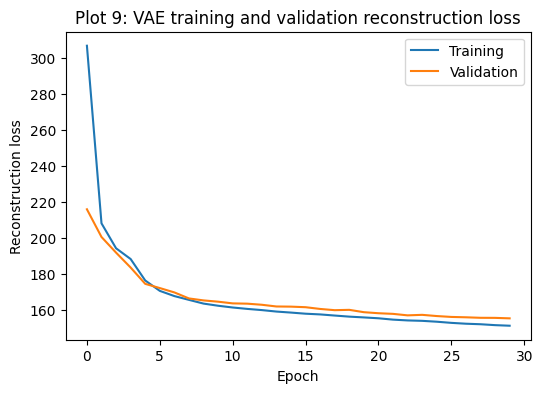

In [40]:
plt.figure(figsize=(6, 4))
plt.plot(vh['rec_loss'], label='Training')
plt.plot(vh['val_rec_loss'], label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Reconstruction loss'); plt.legend()
plt.title('Plot 9: VAE training and validation reconstruction loss')
plt.show()

**VAE metrics table**

In [41]:
mu_t, logvar_t, _ = [t.numpy() for t in encoder(x_test)]
vae_rec = decoder.predict(mu_t, verbose=0)
vae_m = evaluate(x_test, vae_rec)
rec_l, kl_l = [float(v) for v in vae.vae_losses(tf.constant(x_test))]
results['VAE'] = dict(**vae_m, Parameters=encoder.count_params() + decoder.count_params(), Time=vae_time)

pd.DataFrame({'VAE Metric': ['Reconstruction Loss', 'KL Loss', 'Total Loss', 'Test MSE', 'Test MAE', 'Mean SSIM'],
              'Value': [rec_l, kl_l, rec_l + kl_l, vae_m['MSE'], vae_m['MAE'], vae_m['SSIM']]})

,VAE Metric,Value
0,Reconstruction Loss,153.36845
1,KL Loss,5.69516
2,Total Loss,159.06362
3,Test MSE,0.04536
4,Test MAE,0.10687
5,Mean SSIM,0.46529


**Plot 6** – VAE latent space

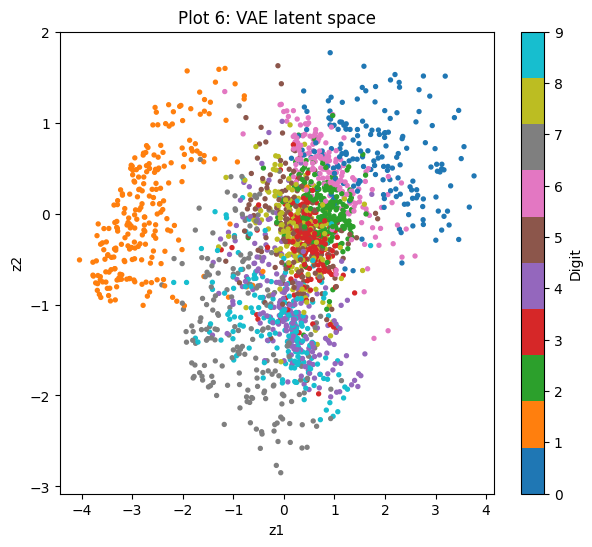

In [42]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(mu_t[:, 0], mu_t[:, 1], c=y_test, cmap='tab10', s=8)
plt.colorbar(sc, ticks=range(10), label='Digit')
plt.xlabel('z1'); plt.ylabel('z2')
plt.title('Plot 6: VAE latent space')
plt.show()

**Plot 7** – 25 generated images from z ~ N(0, I)

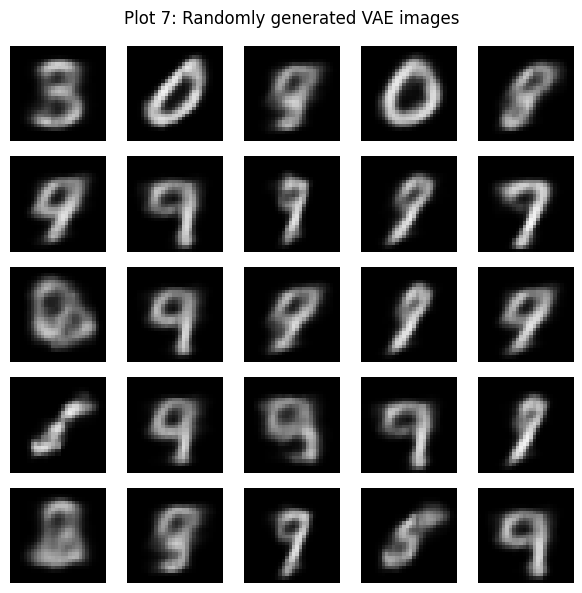

In [43]:
gen = decoder.predict(np.random.normal(size=(25, LATENT)).astype('float32'), verbose=0)
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for a, g in zip(axes.ravel(), gen):
    a.imshow(g.squeeze(), cmap='gray', vmin=0, vmax=1); a.axis('off')
fig.suptitle('Plot 7: Randomly generated VAE images')
plt.tight_layout(); plt.show()

**Plot 8** – Latent-space interpolation

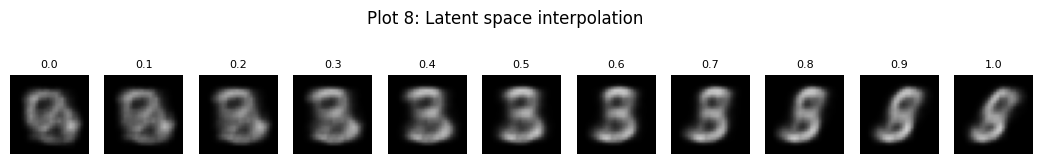

In [44]:
iA, iB = np.where(y_test == 3)[0][0], np.where(y_test == 8)[0][0]
zA, zB = mu_t[iA], mu_t[iB]
alphas = np.round(np.arange(0, 1.01, 0.1), 1)
zs = np.array([(1 - a) * zA + a * zB for a in alphas], dtype='float32')
imgs = decoder.predict(zs, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(len(alphas) * 1.2, 1.8))
for a, im, al in zip(axes, imgs, alphas):
    a.imshow(im.squeeze(), cmap='gray', vmin=0, vmax=1); a.axis('off'); a.set_title(str(al), fontsize=8)
fig.suptitle('Plot 8: Latent space interpolation', y=1.08)
plt.show()

## 5. Reconstruction-error distribution and high-error images (CAE)

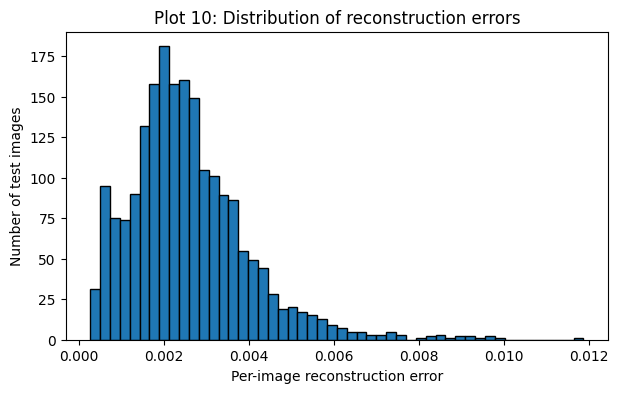

count   2000.00000
mean       0.00258
std        0.00141
min        0.00027
25%        0.00167
50%        0.00236
75%        0.00326
max        0.01188
dtype: float64


In [45]:
e = np.mean((x_test - cae_rec) ** 2, axis=(1, 2, 3))

plt.figure(figsize=(7, 4))
plt.hist(e, bins=50, edgecolor='k')
plt.xlabel('Per-image reconstruction error'); plt.ylabel('Number of test images')
plt.title('Plot 10: Distribution of reconstruction errors')
plt.show()
print(pd.Series(e).describe())

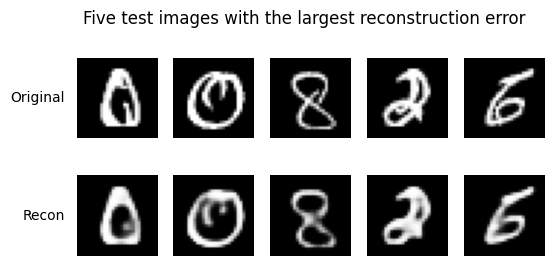

In [46]:
top5 = np.argsort(e)[-5:][::-1]
show_rows([("Original", x_test[top5]), ("Recon", cae_rec[top5])], n=5,
          title="Five test images with the largest reconstruction error")

## 6. Latent-dimension study (basic autoencoder)

,Latent Dimension,MSE,SSIM,Parameters
0,2,0.04561,0.45415,210130
1,8,0.02648,0.68745,210520
2,16,0.02309,0.72429,211040
3,32,0.02091,0.75174,212080


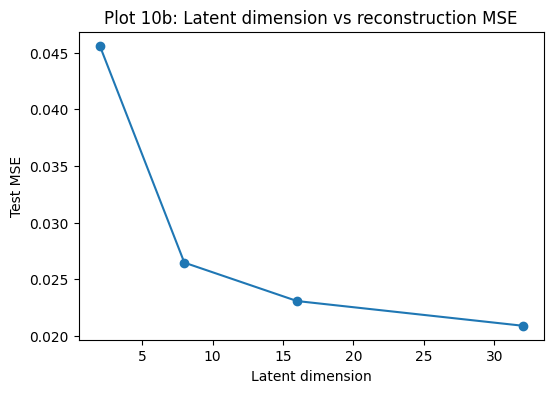

In [47]:
rows = []
for dz in [2, 8, 16, 32]:
    m = build_fc_ae(dz)
    fit_ae(m, x_tr, x_tr, verbose=0)
    met = evaluate(x_test, m.predict(x_test, verbose=0))
    rows.append({'Latent Dimension': dz, 'MSE': met['MSE'], 'SSIM': met['SSIM'], 'Parameters': m.count_params()})
df_lat = pd.DataFrame(rows)
display(df_lat)

plt.figure(figsize=(6, 4))
plt.plot(df_lat['Latent Dimension'], df_lat['MSE'], 'o-')
plt.xlabel('Latent dimension'); plt.ylabel('Test MSE')
plt.title('Plot 10b: Latent dimension vs reconstruction MSE')
plt.show()

## 7. Consolidated results

In [48]:
df_res = pd.DataFrame(results).T[['MSE', 'MAE', 'SSIM', 'Parameters', 'Time']]
df_res['Parameters'] = df_res['Parameters'].astype(int)
df_res.rename(columns={'Time': 'Time (s)'})

,MSE,MAE,SSIM,Parameters,Time (s)
FC Autoencoder,0.02135,0.05662,0.74932,211040,32.95644
Conv. Autoencoder,0.00258,0.01496,0.97423,74497,190.40687
Denoising CAE,0.00494,0.02200,0.94174,74497,166.64772
VAE,0.04536,0.10687,0.46529,134165,206.72349
